# Interactive Script: **get_stac_layers**

**Author:** Baturalp Arisoy

## Contents

1. [How to **get_stac_layers**](#1-how-to-get_stac_layers)
2. [Slice Time and Band](#2-slice-time-and-band)
3. [Calculate Stats](#3-calculate-stats)
4. [Export and Read](#4-export-and-read)
5. [Simple Visualization](#5-simple-visualization)
6. [Graphs and Animation](#6-graphs-and-animation)

---

**Imports**

In [1]:
from stac2ardcube import get_stac_layers
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import ProgressBar
import rioxarray

## 1. How to **get_stac_layers**

**1.1 Set the parameters**

In [2]:
mission = "s2"
polygon = "./polygons/test.gpkg"
resolution = 10
daterange = ["2023-01-01", "2024-12-31"]
bands = ["blue", "green", "red", "nir",]
max_cc = 100
clip_raster = False
cloud_masking = False
indices = ["ndvi", "ndwi"]
output = None # Will return lazy, replace with path to export, preferably with DSS container path
aggregator = None
topographic_features = None
animation = False

**(Optional) 1.1.1 If polygon is not available, select your area below on Leafmap**

In [1]:
#!pip install leafmap
# or
#!micromamba install leafmap
# restart Kernel

import leafmap

**(Optional) 1.1.2 Change the extent**<br>
Adjust the extent and execute the cell. The extent will be bbox.

In [ ]:
m = leafmap.Map(center=[49.787281735930804, 9.978161492015976], zoom=18, height="800px")
m

**(Optional) 1.1.3 Get the bbox coordinate list**

In [ ]:
bbox = (m.west, m.south, m.east, m.north)
polygon = list(bbox)

**1.2 Get Stac Layers, returns lazy xarray.DataArray**

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, 
                            topographic_features=topographic_features, animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 276, band: 6, y: 247, x: 511)> Size: 2GB
dask.array<transpose, shape=(276, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) object 2kB '2023-01-02' '2023-01-04' ... '2024-12-29'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...


In [4]:
stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 276, band: 6, y: 247, x: 511)> Size: 2GB
dask.array<transpose, shape=(276, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) object 2kB '2023-01-02' '2023-01-04' ... '2024-12-29'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**If time coordinate is too long to be printed**

In [5]:
print(stac.time.values)

['2023-01-02' '2023-01-04' '2023-01-07' '2023-01-09' '2023-01-12'
 '2023-01-14' '2023-01-19' '2023-01-22' '2023-01-27' '2023-01-29'
 '2023-02-01' '2023-02-03' '2023-02-06' '2023-02-08' '2023-02-11'
 '2023-02-13' '2023-02-16' '2023-02-21' '2023-02-23' '2023-02-26'
 '2023-02-28' '2023-03-03' '2023-03-05' '2023-03-08' '2023-03-10'
 '2023-03-13' '2023-03-15' '2023-03-18' '2023-03-20' '2023-03-23'
 '2023-03-25' '2023-03-28' '2023-03-30' '2023-04-04' '2023-04-07'
 '2023-04-12' '2023-04-14' '2023-04-17' '2023-04-22' '2023-04-24'
 '2023-04-27' '2023-05-02' '2023-05-07' '2023-05-09' '2023-05-12'
 '2023-05-14' '2023-05-17' '2023-05-19' '2023-05-22' '2023-05-24'
 '2023-05-27' '2023-05-29' '2023-06-01' '2023-06-03' '2023-06-06'
 '2023-06-08' '2023-06-11' '2023-06-13' '2023-06-16' '2023-06-18'
 '2023-06-21' '2023-06-23' '2023-06-26' '2023-06-28' '2023-07-01'
 '2023-07-03' '2023-07-06' '2023-07-08' '2023-07-11' '2023-07-13'
 '2023-07-16' '2023-07-18' '2023-07-21' '2023-07-23' '2023-07-26'
 '2023-07-

**Get stac CRS when required**

In [6]:
print(stac.crs)

PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 35N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",27,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False ea

## 2. Slice Time and Band

**2.1 Slice Time**

**2.1.1 Slice Single Date**

**By exact date**

In [6]:
date = "2024-10-03"
stac_date = stac.sel(time=date)[0]

**Or by the index**

In [21]:
index = 0
stac_date = stac.isel(time=index)

In [7]:
stac_date

<xarray.DataArray 'Spectral_Temporal_Stack' (band: 6, y: 247, x: 511)> Size: 6MB
dask.array<getitem, shape=(6, 247, 511), dtype=float64, chunksize=(1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
    time         datetime64[ns] 8B 2024-10-03T09:08:57.016000
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**2.1.2 Slice Time Range**

In [8]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 146, band: 6, y: 247, x: 511)> Size: 885MB
dask.array<getitem, shape=(146, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 1kB 2024-01-02T09:08:56.242000 ... 202...
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**2.1.2 Slice Multiple Dates**

In [6]:
dates = ['2023-01-02', '2024-12-02', '2024-12-24']
stac_dates = stac.sel(time=dates)
stac_dates

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 3, band: 6, y: 247, x: 511)> Size: 18MB
dask.array<getitem, shape=(3, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) object 24B '2023-01-02' '2024-12-02' '2024-12-24'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**2.2 Slice Bands**

**2.2.1 Slice Single Band**

In [13]:
band = 'ndvi'
stac_ndvi = stac.sel(band=band)
stac_ndvi

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 276, y: 247, x: 511)> Size: 279MB
dask.array<getitem, shape=(276, 247, 511), dtype=float64, chunksize=(1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
    band         <U5 20B 'ndvi'
  * time         (time) object 2kB '2023-01-02' '2023-01-04' ... '2024-12-29'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**2.2.2 Slice Multiple Bands**

In [12]:
bands = ['red', 'green', 'blue']
stac_rgb = stac.sel(band=bands)
stac_rgb

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 276, band: 3, y: 247, x: 511)> Size: 836MB
dask.array<getitem, shape=(276, 3, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 60B 'red' 'green' 'blue'
  * time         (time) object 2kB '2023-01-02' '2023-01-04' ... '2024-12-29'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

**2.3 Slice both Time and Band**

In [14]:
daterange = ["2024-01-01", "2024-12-31"]
bands = ['red', 'green', 'blue']

stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_rgb = stac_2024.sel(band=bands)
stac_2024_rgb

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 146, band: 3, y: 247, x: 511)> Size: 442MB
dask.array<getitem, shape=(146, 3, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 60B 'red' 'green' 'blue'
  * time         (time) object 1kB '2024-01-02' '2024-01-04' ... '2024-12-29'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n| 0.00...

## 3. Calculate Stats

**Some stat calculations can be done prior to compute**

**3.1 Calculate a single stat for a given daterange**

In [26]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_mean = stac_2024.mean(dim='time')
stac_2024_mean

<xarray.DataArray 'Spectral_Temporal_Stack' (band: 6, y: 247, x: 511)> Size: 6MB
dask.array<mean_agg-aggregate, shape=(6, 247, 511), dtype=float64, chunksize=(1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'

**3.2 Calculate selected stats for a given daterange**

In [9]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))

stats = ['mean', 'median', 'std', 'max', 'min']
stac_2024_stats = {stat: getattr(stac_2024, stat)(dim='time') for stat in stats}

**Select desired stat**

In [10]:
stac_2024_stats['median']

<xarray.DataArray 'Spectral_Temporal_Stack' (band: 6, y: 247, x: 511)> Size: 6MB
dask.array<nanmedian, shape=(6, 247, 511), dtype=float64, chunksize=(1, 235, 487), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'

## 4. Export and Read

**4.1 Export as NETCDF**

In [44]:
daterange = ["2024-06-01", "2024-06-05"]
stac_sel = stac.sel(time=slice(*daterange))

if dask.is_dask_collection(stac_sel):
    with ProgressBar():
        img = stac_sel.compute()

img.to_netcdf("./results/test.nc")

[########################################] | 100% Completed | 20.96 s


**4.2 Export as Cloud Optimized Geotifs (COGs)**

> **Note:**
> Geotiff format cannot handle 4 dimensional system. Therefore each time has to be exported separately.

In [77]:
stac_cog = stac_sel.to_dataset(dim='band')
output_dir = './results/cogs/'

for i in range(len(stac_cog.time)):
    single_timestamp = stac_cog.isel(time=i)
    date_str = str(single_timestamp.time.values)[:10]
    print(f'Writing {date_str}')
    output_file = f'{output_dir}{date_str}.tif'    
    single_timestamp.rio.to_raster(output_file, driver='COG', dtype='float32', compress='deflate')

Writing 2024-06-02
Writing 2024-06-05
Writing 2024-06-07
Writing 2024-06-10


**4.3 Read NETCDF**

> **Note:**
> STAC layers are stored under dataarray not dataset, however NETCDFs should be read as dataset first.

**Read NETCDF as dataset**

In [45]:
img = ("./results/test.nc")

dataset = xr.open_dataset(img)
dataset

<xarray.Dataset> Size: 24MB
Dimensions:                  (y: 247, x: 511, band: 6, time: 4)
Coordinates:
  * y                        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06
  * x                        (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05
    spatial_ref              int32 4B ...
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
  * time                     (time) <U10 160B '2024-06-02' ... '2024-06-10'
Data variables:
    Spectral_Temporal_Stack  (time, band, y, x) float64 24MB ...

**Select Spectral Temporal Stack as dataarray**

In [46]:
dataarray = dataset.Spectral_Temporal_Stack
dataarray

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 247, x: 511)> Size: 24MB
[3029208 values with dtype=float64]
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B ...
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) <U10 160B '2024-06-02' '2024-06-05' ... '2024-06-10'
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  [ 1.00000e+01  0.00000e+00  6.67020e+05  0.00000e+00 -1.00000...

In [1]:
from stac2ardcube import get_stac_layers
stats = ['mean', 'median', 'std', 'min', 'max']
mission = "s2"
polygon = "./polygons/test.gpkg"
resolution = 10
daterange = ["2024-06-01", "2024-06-10"]
bands = ["blue", "green", "red", "nir",]
max_cc = 100
clip_raster = False
cloud_masking = False
indices = ["ndvi", "ndwi"]
output = "./results/test2.nc"
aggregator = None
topographic_features = None
animation = False

get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, 
                            topographic_features=topographic_features, animation=animation, stats=stats)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 247, x: 511)> Size: 24MB
dask.array<transpose, shape=(4, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) object 32B '2024-06-02' '2024-06-05' ... '2024-06-10'
['2024-06-02' '2024-06-05' '2024-06-07' '2024-06-10']
['blue' 'green' 'red' 'nir' 'ndvi' 'ndwi']
[########################################] | 100% Completed | 13.42 s
Export is done: ./results/test2.nc


In [3]:
import xarray as xr
img = ("./results/test2.nc")

dataset = xr.open_dataset(img)
dataset

<xarray.Dataset> Size: 55MB
Dimensions:                  (y: 247, x: 511, band: 6, time: 4)
Coordinates:
  * y                        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06
  * x                        (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
  * time                     (time) <U10 160B '2024-06-02' ... '2024-06-10'
Data variables:
    Spectral_Temporal_Stack  (time, band, y, x) float64 24MB ...
    mean_imagery             (band, y, x) float64 6MB ...
    median_imagery           (band, y, x) float64 6MB ...
    std_imagery              (band, y, x) float64 6MB ...
    min_imagery              (band, y, x) float64 6MB ...
    max_imagery              (band, y, x) float64 6MB ...
    spatial_ref              int64 8B ...
Attributes:
    crs:        PROJCRS["WGS 84 / UTM zone 35N",BASEGEOGCRS["WGS 84",ENSEMBLE...
    transform:  [ 1.00000e+01  0.00000e+00  6.67020e+05  0.00000e+00 -1.00000...

In [4]:
dataset.Spectral_Temporal_Stack

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 247, x: 511)> Size: 24MB
[3029208 values with dtype=float64]
Coordinates:
  * y        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x        (x) float64 4kB 6.67e+05 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time     (time) <U10 160B '2024-06-02' '2024-06-05' ... '2024-06-10'
Attributes:
    grid_mapping:  spatial_ref

In [5]:
dataset.mean_imagery

<xarray.DataArray 'mean_imagery' (band: 6, y: 247, x: 511)> Size: 6MB
[757302 values with dtype=float64]
Coordinates:
  * y        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x        (x) float64 4kB 6.67e+05 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
Attributes:
    grid_mapping:  spatial_ref

In [4]:
import xarray as xr

def calculate_statistics(stac, stats):
    
    computed_stats = {}
    for stat in stats:
        stat_key = f"{stat}_imagery"
        try:
            # Retrieve the statistic function from stac using getattr
            stat_func = getattr(stac, stat)
        except AttributeError:
            raise ValueError(f"Statistic '{stat}' is not supported.")
        computed_stats[stat_key] = stat_func(dim='time')
    
    dataset = xr.Dataset({"Spectral_Temporal_Stack": stac, **computed_stats})
    return dataset

stats = ['mean', 'median', 'std', 'min', 'max']
calculate_statistics(stac, stats)

<xarray.Dataset> Size: 2GB
Dimensions:                  (y: 247, x: 511, band: 6, time: 276)
Coordinates:
  * y                        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06
  * x                        (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05
    spatial_ref              int32 4B 32635
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
  * time                     (time) object 2kB '2023-01-02' ... '2024-12-29'
Data variables:
    Spectral_Temporal_Stack  (time, band, y, x) float64 2GB dask.array<chunksize=(1, 1, 247, 511), meta=np.ndarray>
    mean_imagery             (band, y, x) float64 6MB dask.array<chunksize=(1, 247, 511), meta=np.ndarray>
    median_imagery           (band, y, x) float64 6MB dask.array<chunksize=(1, 171, 354), meta=np.ndarray>
    std_imagery              (band, y, x) float64 6MB dask.array<chunksize=(1, 247, 511), meta=np.ndarray>
    min_imagery              (band, y, x) float64 6MB dask.array<chunksize=(1, 247, 511), meta=np.ndarray>
    max_imagery              (band, y, x) float64 6MB dask.array<chunksize=(1, 247, 511), meta=np.ndarray>

In [41]:
import matplotlib.pyplot as plt
import numpy as np
time_index = 10
da_time = stac.isel(time=time_index)

# Select the bands by their names
da_rgb = da_time.sel(band=["red", "green", "blue"])
rgb_image = da_rgb.values.transpose(1, 2, 0)

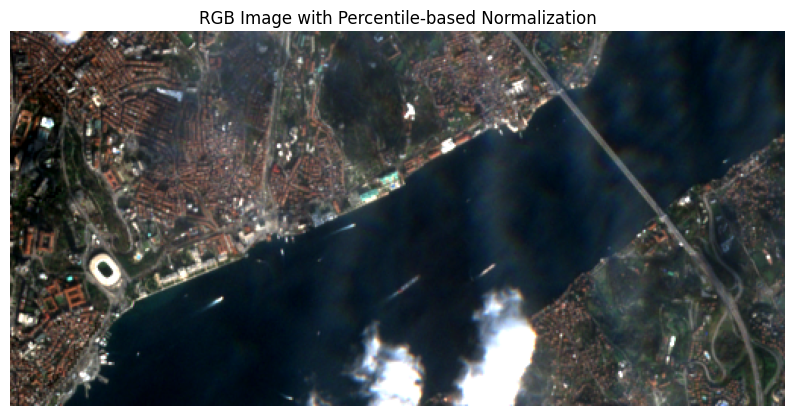

In [42]:
p2 = np.percentile(rgb_image, 2)
p98 = np.percentile(rgb_image, 98)

# Clip and normalize the image
rgb_clipped = np.clip(rgb_image, p2, p98)
rgb_normalized = (rgb_clipped - p2) / (p98 - p2)

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(rgb_normalized)
plt.title("RGB Image with Percentile-based Normalization")
plt.axis("off")
plt.show()